# Statystyka - dane sprzedażowe

Notebook prowadzi analizę na danych sprzedażowych krok po kroku:

1. Utworzenie danych
2. Obliczenie statystyk danych
3. Analiza braków danych
4. Wykres ramka-wąsy
5. Test istotności różnic
6. Test zgodności chi-kwadrat
7. Przedział ufności dla średniej
8. Współczynnik korelacji Pearsona i Spearmana
9. Weryfikacja współczynników w modelu liniowym
10. Analiza szeregów czasowych i metody wygładzania

Dla części czasowej wybieram serię o długości większej niż okresowość, tak aby dało się sensownie porównać co najmniej 2-3 pełne okresy sezonowe.


In [ ]:
# %pip install pandas matplotlib matplotlib scipy statsmodels IPython

In [ ]:
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
from pathlib import Path
from IPython.display import display


data_dir = Path("data")

calendar = pd.read_csv(data_dir / "calendar.csv")
sales_train_validation = pd.read_csv(data_dir / "sales_train_validation.csv", low_memory=False)
sales_train_evaluation = pd.read_csv(data_dir / "sales_train_evaluation.csv", low_memory=False)
sample_submission = pd.read_csv(data_dir / "sample_submission.csv")
sell_prices = pd.read_csv(data_dir / "sell_prices.csv", low_memory=False)

day_cols = [column for column in sales_train_validation.columns if column.startswith("d_")]
calendar["date"] = pd.to_datetime(calendar["date"])
calendar_by_day = calendar.set_index("d")

print("Wczytane zbiory:")
for name, df in {
    "calendar": calendar,
    "sales_train_validation": sales_train_validation,
    "sales_train_evaluation": sales_train_evaluation,
    "sample_submission": sample_submission,
    "sell_prices": sell_prices,
}.items():
    print(f"- {name}: {df.shape[0]:,} wierszy, {df.shape[1]:,} kolumn")

print("\nPodgląd calendar:")
display(calendar.head())

print("\nPodgląd sales_train_validation:")
display(sales_train_validation.head())


Wczytane zbiory:
- calendar: 1,969 wierszy, 14 kolumn
- sales_train_validation: 30,490 wierszy, 1,919 kolumn
- sales_train_evaluation: 30,490 wierszy, 1,947 kolumn
- sample_submission: 60,980 wierszy, 29 kolumn
- sell_prices: 6,841,121 wierszy, 4 kolumn

Podgląd calendar:


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1



Podgląd sales_train_validation:


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


Top 20 produktów w kategorii FOODS według łącznej liczby sprzedanych sztuk:


,id,item_id,dept_id,store_id,total_sales,mean_daily_sales
0,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,CA_3,250502,130.947203
1,FOODS_3_586_TX_2_validation,FOODS_3_586,FOODS_3,TX_2,192835,100.802405
2,FOODS_3_586_TX_3_validation,FOODS_3_586,FOODS_3,TX_3,150122,78.474647
3,FOODS_3_586_CA_3_validation,FOODS_3_586,FOODS_3,CA_3,134386,70.248824
4,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,CA_1,127203,66.493988
5,FOODS_3_090_WI_3_validation,FOODS_3_090,FOODS_3,WI_3,121434,63.478306
6,FOODS_3_090_TX_2_validation,FOODS_3_090,FOODS_3,TX_2,119496,62.465238
7,FOODS_3_090_TX_3_validation,FOODS_3_090,FOODS_3,TX_3,114854,60.038683
8,FOODS_3_252_TX_2_validation,FOODS_3_252,FOODS_3,TX_2,114153,59.672243
9,FOODS_3_586_TX_1_validation,FOODS_3_586,FOODS_3,TX_1,112454,58.784109



Wybrana seria do dalszej analizy: item_id=FOODS_3_090, store_id=CA_3


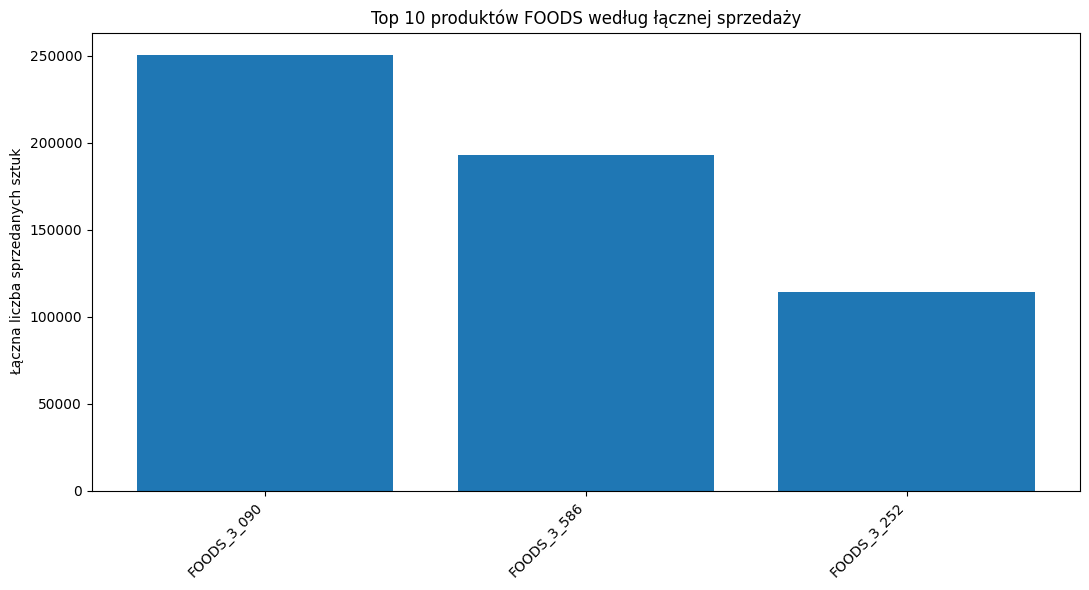

In [ ]:
# Analiza: najlepsze produkty w kategorii FOODS
from matplotlib import pyplot as plt

foods = sales_train_validation[sales_train_validation["cat_id"] == "FOODS"].copy()
foods["total_sales"] = foods[day_cols].sum(axis=1)
foods["mean_daily_sales"] = foods[day_cols].mean(axis=1)

top_foods = foods.sort_values("total_sales", ascending=False).reset_index(drop=True)
chosen_row = top_foods.iloc[0]
chosen_item_id = chosen_row["item_id"]
chosen_store_id = chosen_row["store_id"]
chosen_sales_series = pd.Series(chosen_row[day_cols].to_numpy(dtype=float), index=day_cols, name="sales")

print("Top 20 produktów w kategorii FOODS według łącznej liczby sprzedanych sztuk:")
display(top_foods.loc[:, ["id", "item_id", "dept_id", "store_id", "total_sales", "mean_daily_sales"]].head(20))
print(f"\nWybrana seria do dalszej analizy: item_id={chosen_item_id}, store_id={chosen_store_id}")

plt.figure(figsize=(11, 6))
plt.bar(top_foods["item_id"].head(10), top_foods["total_sales"].head(10))
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 produktów FOODS według łącznej sprzedaży")
plt.ylabel("Łączna liczba sprzedanych sztuk")
plt.tight_layout()
plt.show()


,wartość
liczność,1913.000000
średnia,130.947203
mediana,126.000000
odchylenie standardowe,108.611717
wariancja,11796.505056
minimum,0.000000
Q1,28.000000
Q3,189.000000
maksimum,763.000000
skośność,1.076600



3. Analiza braków danych


,zbiór,brakujące komórki,procent braków
0,calendar,7542,27.359791
1,sales_train_validation,0,0.000000
2,sales_train_evaluation,0,0.000000
3,sample_submission,0,0.000000
4,sell_prices,0,0.000000


W szeregu sprzedażowym zera są prawdziwą sprzedażą, a nie brakami danych; braki w calendar i sell_prices dotyczą głównie pól opisowych i zdarzeń specjalnych.

4. Wykres ramka-wąsy


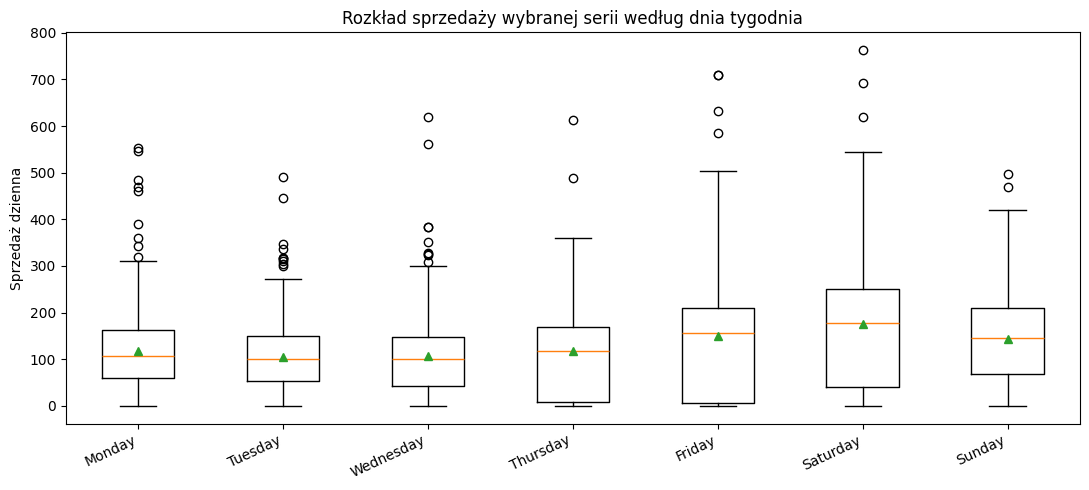

In [ ]:
# 2. Obliczenie statystyk danych
analysis_series = chosen_sales_series.astype(float)
analysis_frame = pd.DataFrame({"d": analysis_series.index, "sales": analysis_series.values}).merge(
    calendar[["d", "date", "weekday", "wm_yr_wk"]],
    on="d",
    how="left",
)

statystyki = pd.Series(
    {
        "liczność": analysis_series.size,
        "średnia": analysis_series.mean(),
        "mediana": analysis_series.median(),
        "odchylenie standardowe": analysis_series.std(ddof=1),
        "wariancja": analysis_series.var(ddof=1),
        "minimum": analysis_series.min(),
        "Q1": analysis_series.quantile(0.25),
        "Q3": analysis_series.quantile(0.75),
        "maksimum": analysis_series.max(),
        "skośność": analysis_series.skew(),
        "kurtoza": analysis_series.kurtosis(),
    }
)

display(statystyki.to_frame(name="wartość"))

print("\n3. Analiza braków danych")
missing_summary = pd.DataFrame(
    {
        "zbiór": [
            "calendar",
            "sales_train_validation",
            "sales_train_evaluation",
            "sample_submission",
            "sell_prices",
        ],
        "brakujące komórki": [
            int(calendar.isna().sum().sum()),
            int(sales_train_validation.isna().sum().sum()),
            int(sales_train_evaluation.isna().sum().sum()),
            int(sample_submission.isna().sum().sum()),
            int(sell_prices.isna().sum().sum()),
        ],
        "procent braków": [
            100 * calendar.isna().sum().sum() / calendar.size,
            100 * sales_train_validation.isna().sum().sum() / sales_train_validation.size,
            100 * sales_train_evaluation.isna().sum().sum() / sales_train_evaluation.size,
            100 * sample_submission.isna().sum().sum() / sample_submission.size,
            100 * sell_prices.isna().sum().sum() / sell_prices.size,
        ],
    }
)
display(missing_summary)
print(
    "W szeregu sprzedażowym zera są prawdziwą sprzedażą, a nie brakami danych; "
    "braki w calendar i sell_prices dotyczą głównie pól opisowych i zdarzeń specjalnych."
)

print("\n4. Wykres ramka-wąsy")
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_groups = [
    analysis_frame.loc[analysis_frame["weekday"] == weekday, "sales"].to_numpy()
    for weekday in weekday_order
]

plt.figure(figsize=(11, 5))
plt.boxplot(weekday_groups, tick_labels=weekday_order, showmeans=True)
plt.xticks(rotation=25, ha="right")
plt.title("Rozkład sprzedaży wybranej serii według dnia tygodnia")
plt.ylabel("Sprzedaż dzienna")
plt.tight_layout()
plt.show()


5. Test istotności różnic


,test,statystyka,p-value
0,normaltest wybrana seria,13.551227,1.141270e-03
1,normaltest seria porownawcza,10.206537,6.076852e-03
2,ttest niezalezne,5.313307,2.113636e-07
3,Mann-Whitney U,50576.000000,1.985955e-12
4,ttest zalezne,19.621595,4.430624e-54
5,Wilcoxon,135.000000,6.843323e-41



6. Test zgodności chi-kwadrat


,weekday,obserwowane,oczekiwane
0,Monday,32274.0,35786.0
1,Tuesday,28731.0,35786.0
2,Wednesday,29345.0,35786.0
3,Thursday,31965.0,35786.0
4,Friday,40768.0,35786.0
5,Saturday,47975.0,35786.0
6,Sunday,39444.0,35786.0


chi2 = 8521.956, p-value = 0

7. Przedział ufności dla średniej
95% CI dla średniej dziennej sprzedaży: (126.077, 135.817)

8. Korelacja Pearsona i Spearmana


,miara,współczynnik,p-value
0,Pearson,0.117314,0.052413
1,Spearman,0.048633,0.422663



9. Weryfikacja współczynników w modelu liniowym


,parametr,p-value,błąd std.
Intercept,291.049838,0.367135,322.186262
sell_price,464.979289,0.052413,238.664782


R-squared = 0.0138

10. Analiza szeregów czasowych


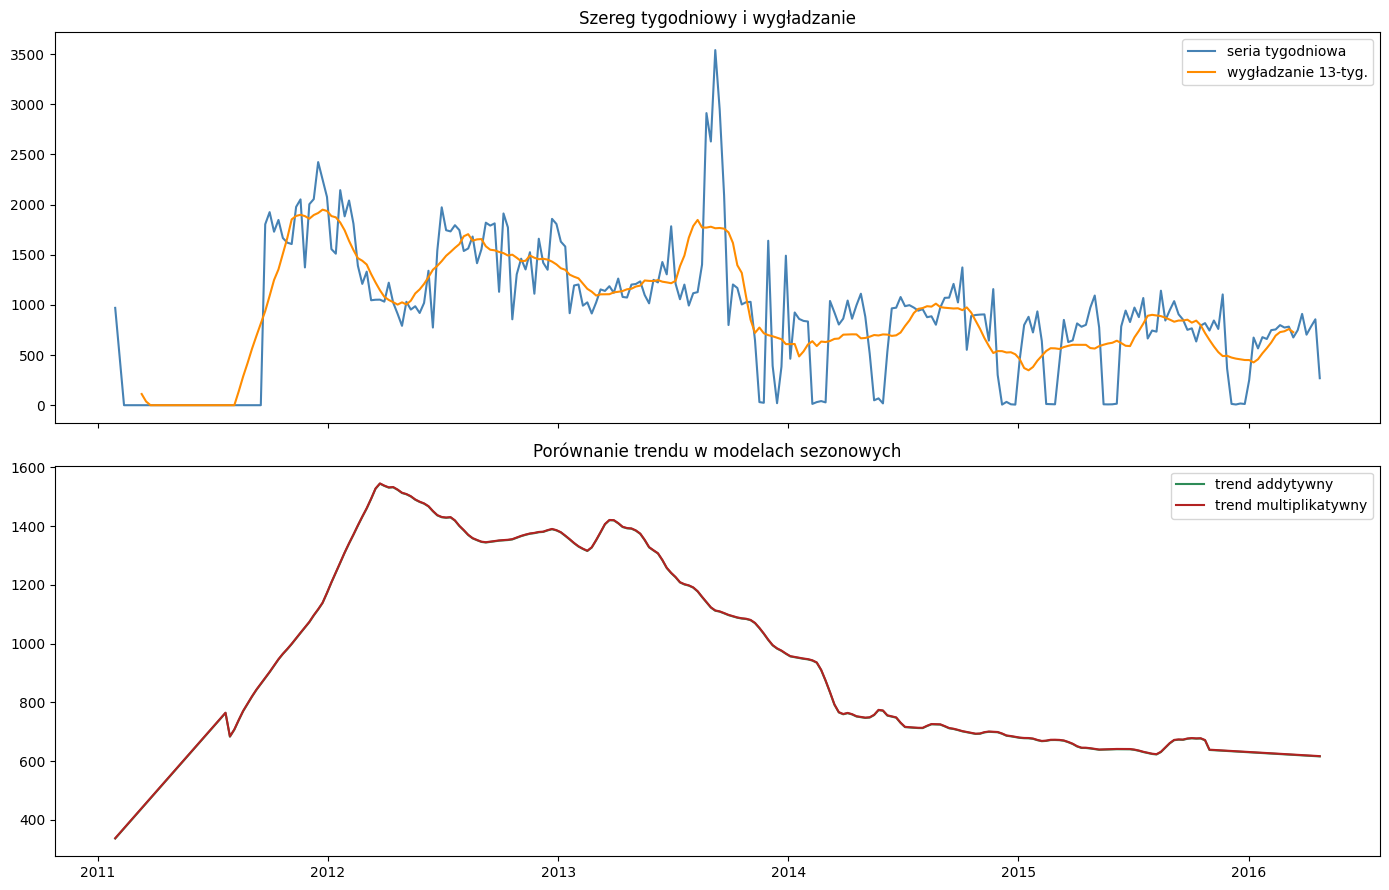

Seria tygodniowa ma 274 obserwacji, co pozwala na sezonowość roczną 52-tygodniową i kilka pełnych cykli w szeregu.


In [ ]:
# 5. Test istotności różnic, 6. Test zgodności chi-kwadrat, 7. Przedział ufności, 8. Korelacje, 9. Model liniowy, 10. Szeregi czasowe

def build_weekly_sales(row: pd.Series) -> pd.DataFrame:
    frame = pd.DataFrame({"d": day_cols, "sales": row[day_cols].to_numpy(dtype=float)})
    frame = frame.merge(calendar[["d", "date", "wm_yr_wk", "weekday"]], on="d", how="left")
    weekly = (
        frame.groupby("wm_yr_wk", as_index=False)
        .agg(sales=("sales", "sum"), date=("date", "min"))
        .sort_values("date")
        .reset_index(drop=True)
    )
    weekly["date"] = pd.to_datetime(weekly["date"])
    return weekly

comparison_row = top_foods.iloc[1]
comparison_sales = build_weekly_sales(comparison_row)
chosen_weekly_sales = build_weekly_sales(chosen_row)

print("5. Test istotności różnic")
normality_chosen = stats.normaltest(chosen_weekly_sales["sales"])
normality_comparison = stats.normaltest(comparison_sales["sales"])
independent_ttest = stats.ttest_ind(chosen_weekly_sales["sales"], comparison_sales["sales"], equal_var=False)
independent_mwu = stats.mannwhitneyu(chosen_weekly_sales["sales"], comparison_sales["sales"], alternative="two-sided")

same_item_other_store = sales_train_validation[
    (sales_train_validation["item_id"] == chosen_item_id)
    & (sales_train_validation["store_id"] != chosen_store_id)
].iloc[0]
paired_sales = build_weekly_sales(same_item_other_store)
paired_frame = chosen_weekly_sales.merge(paired_sales, on="wm_yr_wk", suffixes=("_chosen", "_other"))
paired_ttest = stats.ttest_rel(paired_frame["sales_chosen"], paired_frame["sales_other"])
paired_wilcoxon = stats.wilcoxon(paired_frame["sales_chosen"], paired_frame["sales_other"], zero_method="wilcox")

display(
    pd.DataFrame(
        {
            "test": [
                "normaltest wybrana seria",
                "normaltest seria porownawcza",
                "ttest niezalezne",
                "Mann-Whitney U",
                "ttest zalezne",
                "Wilcoxon",
            ],
            "statystyka": [
                normality_chosen.statistic,
                normality_comparison.statistic,
                independent_ttest.statistic,
                independent_mwu.statistic,
                paired_ttest.statistic,
                paired_wilcoxon.statistic,
            ],
            "p-value": [
                normality_chosen.pvalue,
                normality_comparison.pvalue,
                independent_ttest.pvalue,
                independent_mwu.pvalue,
                paired_ttest.pvalue,
                paired_wilcoxon.pvalue,
            ],
        }
    )
)

print("\n6. Test zgodności chi-kwadrat")
weekday_totals = analysis_frame.groupby("weekday")["sales"].sum().reindex(weekday_order)
expected_totals = np.repeat(weekday_totals.sum() / len(weekday_totals), len(weekday_totals))
chi_square_result = stats.chisquare(f_obs=weekday_totals, f_exp=expected_totals)
display(
    pd.DataFrame(
        {
            "weekday": weekday_order,
            "obserwowane": weekday_totals.to_numpy(),
            "oczekiwane": expected_totals,
        }
    )
)
print(f"chi2 = {chi_square_result.statistic:.3f}, p-value = {chi_square_result.pvalue:.4g}")

print("\n7. Przedział ufności dla średniej")
confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(analysis_series) - 1,
    loc=analysis_series.mean(),
    scale=stats.sem(analysis_series),
)
print(f"95% CI dla średniej dziennej sprzedaży: ({confidence_interval[0]:.3f}, {confidence_interval[1]:.3f})")

print("\n8. Korelacja Pearsona i Spearmana")
price_weekly = sell_prices[
    (sell_prices["item_id"] == chosen_item_id)
    & (sell_prices["store_id"] == chosen_store_id)
][["wm_yr_wk", "sell_price"]]
price_sales = chosen_weekly_sales[["wm_yr_wk", "sales"]].merge(price_weekly, on="wm_yr_wk", how="inner")
pearson_result = stats.pearsonr(price_sales["sell_price"], price_sales["sales"])
spearman_result = stats.spearmanr(price_sales["sell_price"], price_sales["sales"])
display(
    pd.DataFrame(
        {
            "miara": ["Pearson", "Spearman"],
            "współczynnik": [pearson_result.statistic, spearman_result.statistic],
            "p-value": [pearson_result.pvalue, spearman_result.pvalue],
        }
    )
)

print("\n9. Weryfikacja współczynników w modelu liniowym")
linear_model = ols("sales ~ sell_price", data=price_sales).fit()
display(pd.DataFrame({"parametr": linear_model.params, "p-value": linear_model.pvalues, "błąd std.": linear_model.bse}))
print(f"R-squared = {linear_model.rsquared:.4f}")

print("\n10. Analiza szeregów czasowych")
weekly_time_series = chosen_weekly_sales.set_index("date")["sales"].sort_index()
weekly_time_series = weekly_time_series.asfreq("W-SAT")

a_additive = seasonal_decompose(weekly_time_series, model="additive", period=52, extrapolate_trend="freq")
a_multiplicative = seasonal_decompose(weekly_time_series + 1, model="multiplicative", period=52, extrapolate_trend="freq")
smoothed_series = weekly_time_series.rolling(window=13, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(weekly_time_series.index, weekly_time_series.values, label="seria tygodniowa", color="steelblue")
axes[0].plot(smoothed_series.index, smoothed_series.values, label="wygładzanie 13-tyg.", color="darkorange")
axes[0].set_title("Szereg tygodniowy i wygładzanie")
axes[0].legend()

axes[1].plot(a_additive.trend.index, a_additive.trend.values, label="trend addytywny", color="seagreen")
axes[1].plot(a_multiplicative.trend.index, a_multiplicative.trend.values, label="trend multiplikatywny", color="firebrick")
axes[1].set_title("Porównanie trendu w modelach sezonowych")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Seria tygodniowa ma", len(weekly_time_series), "obserwacji, co pozwala na sezonowość roczną 52-tygodniową i kilka pełnych cykli w szeregu.")


## 11. Scenariusz biznesowy: prognoza popytu i backtesting

Wersja biznesowa notebooka odpowiada na pytanie: czy da się przewidzieć sprzedaż najlepiej rotującego produktu i użyć tego do planowania zapasu na kolejny rok. Ostatnie 52 tygodnie traktuję jako ukryty okres testowy, a model trenuję wyłącznie na danych wcześniejszych.


,model,MAE,RMSE,WAPE
0,Holt-Winters,513.237902,632.360118,0.773307
1,Seasonal naive,194.096154,282.255578,0.292449


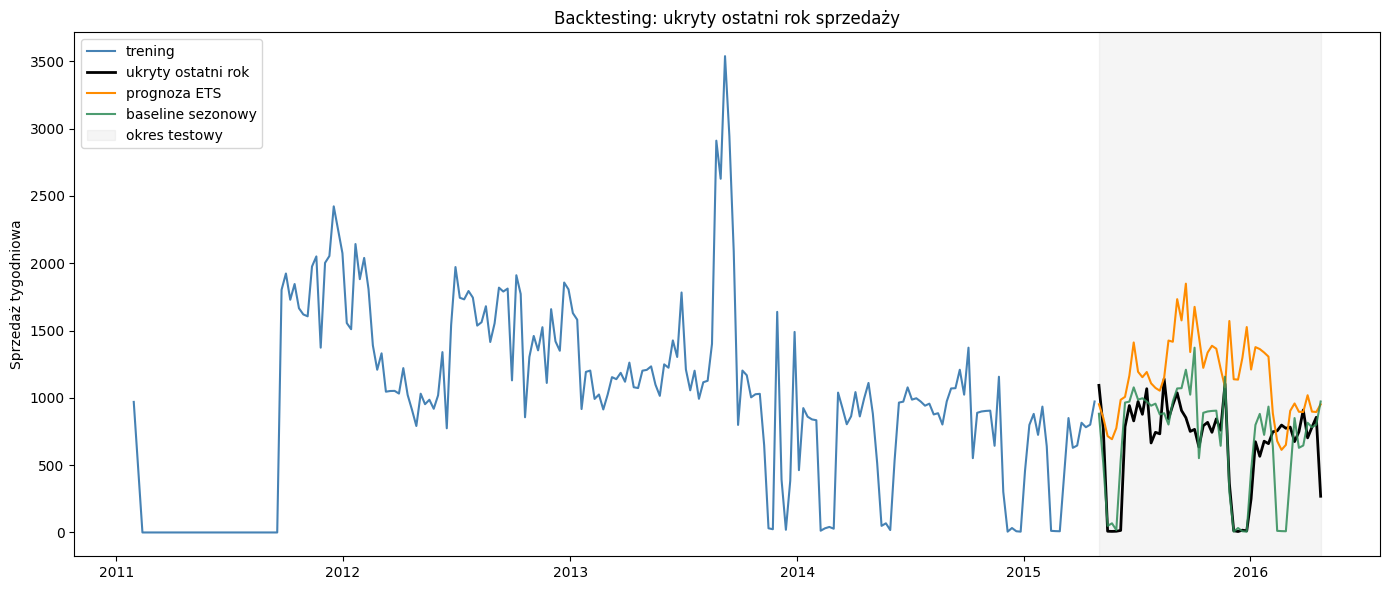

Najlepszy wariant na tym holdoucie to Seasonal naive (WAPE=0.292).
Wniosek biznesowy: jeśli celem jest planowanie zapasu, prosty sezonowy baseline jest bardzo mocnym punktem odniesienia i warto go utrzymywać obok bardziej złożonych modeli.


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

business_series = chosen_weekly_sales[["date", "sales"]].copy().set_index("date")["sales"].asfreq("W-SAT")
holdout_weeks = 52
train_series = business_series.iloc[:-holdout_weeks]
test_series = business_series.iloc[-holdout_weeks:]

holt_winters_model = ExponentialSmoothing(
    train_series,
    trend=None,
    seasonal="add",
    seasonal_periods=52,
    initialization_method="estimated",
).fit(optimized=True)

forecast_hw = holt_winters_model.forecast(holdout_weeks)
seasonal_naive = train_series.iloc[-52:].to_numpy()
seasonal_naive = pd.Series(seasonal_naive, index=test_series.index, name="seasonal_naive")

forecast_frame = pd.DataFrame(
    {
        "actual": test_series,
        "holt_winters": forecast_hw,
        "seasonal_naive": seasonal_naive,
    }
)


def wape(y_true: pd.Series, y_pred: pd.Series) -> float:
    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        return np.nan
    return float(np.sum(np.abs(y_true - y_pred)) / denominator)


business_metrics = pd.DataFrame(
    {
        "model": ["Holt-Winters", "Seasonal naive"],
        "MAE": [
            np.mean(np.abs(forecast_frame["actual"] - forecast_frame["holt_winters"])),
            np.mean(np.abs(forecast_frame["actual"] - forecast_frame["seasonal_naive"])),
        ],
        "RMSE": [
            np.sqrt(np.mean((forecast_frame["actual"] - forecast_frame["holt_winters"]) ** 2)),
            np.sqrt(np.mean((forecast_frame["actual"] - forecast_frame["seasonal_naive"]) ** 2)),
        ],
        "WAPE": [
            wape(forecast_frame["actual"], forecast_frame["holt_winters"]),
            wape(forecast_frame["actual"], forecast_frame["seasonal_naive"]),
        ],
    }
)

best_model = business_metrics.sort_values("WAPE").iloc[0]
display(business_metrics)

plt.figure(figsize=(14, 6))
plt.plot(train_series.index, train_series.values, label="trening", color="steelblue")
plt.plot(test_series.index, test_series.values, label="ukryty ostatni rok", color="black", linewidth=2)
plt.plot(forecast_frame.index, forecast_frame["holt_winters"], label="prognoza ETS", color="darkorange")
plt.plot(forecast_frame.index, forecast_frame["seasonal_naive"], label="baseline sezonowy", color="seagreen", alpha=0.85)
plt.axvspan(test_series.index.min(), test_series.index.max(), color="gray", alpha=0.08, label="okres testowy")
plt.title("Backtesting: ukryty ostatni rok sprzedaży")
plt.ylabel("Sprzedaż tygodniowa")
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Najlepszy wariant na tym holdoucie to {best_model['model']} "
    f"(WAPE={best_model['WAPE']:.3f})."
)
print(
    "Wniosek biznesowy: jeśli celem jest planowanie zapasu, prosty sezonowy baseline jest bardzo mocnym punktem odniesienia "
    "i warto go utrzymywać obok bardziej złożonych modeli."
)


In [ ]:
# 12. Rozszerzone porównanie modeli: ETS vs SARIMAX vs GradientBoosting (rolling CV)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

series = business_series.copy()
min_train_weeks = 104
test_window = 13
fold_results = []

lags = [1,2,3,4,52]

for test_start in range(min_train_weeks, len(series) - test_window + 1, test_window):
    train = series.iloc[:test_start].copy()
    test = series.iloc[test_start:test_start + test_window].copy()

    # ETS (Holt-Winters)
    try:
        ets_model = ExponentialSmoothing(train, trend=None, seasonal="add", seasonal_periods=52).fit(optimized=True)
        ets_pred = ets_model.forecast(len(test))
    except Exception as e:
        ets_pred = pd.Series(np.nan, index=test.index)

    # SARIMAX
    try:
        sar = SARIMAX(train, order=(1,0,1), seasonal_order=(1,1,1,52), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        sar_pred = sar.get_forecast(steps=len(test)).predicted_mean
        sar_pred.index = test.index
    except Exception as e:
        sar_pred = pd.Series(np.nan, index=test.index)

    # GradientBoosting with lag features (recursive forecasting)
    def gb_recursive_forecast(train_series, n_steps, lags):
        model = GradientBoostingRegressor(n_estimators=100, max_depth=3)
        df = pd.DataFrame({'y': train_series})
        for l in lags:
            df[f'lag_{l}'] = df['y'].shift(l)
        train_df = df.dropna()
        X_train = train_df[[f'lag_{l}' for l in lags]].values
        y_train = train_df['y'].values
        if len(y_train) < 10:
            return pd.Series(np.nan, index=pd.date_range(start=train_series.index[-1] + pd.Timedelta(days=7), periods=n_steps, freq='W-SAT'))
        model.fit(X_train, y_train)
        history = train_series.copy()
        preds = []
        for _ in range(n_steps):
            row = []
            for l in lags:
                if len(history) - l >= 0:
                    row.append(history.iloc[-l])
                else:
                    row.append(0.0)
            pred = model.predict([row])[0]
            preds.append(pred)
            # append prediction to history (use concat for pandas >=1.4 compatibility)
            new_index = history.index[-1] + pd.Timedelta(days=7)
            history = pd.concat([history, pd.Series([pred], index=[new_index])])
        return pd.Series(preds, index=test.index)

    gb_pred = gb_recursive_forecast(train, len(test), lags)

    # Metrics
    def mae(a,b):
        return np.mean(np.abs(a - b))
    def rmse(a,b):
        return np.sqrt(np.mean((a - b)**2))
    def wape(a,b):
        denom = np.sum(np.abs(a))
        return np.sum(np.abs(a-b))/denom if denom!=0 else np.nan

    fold_results.append({
        'fold_start': train.index[-1],
        'ets_mae': mae(test.values, ets_pred.values),
        'ets_rmse': rmse(test.values, ets_pred.values),
        'ets_wape': wape(test.values, ets_pred.values),
        'sar_mae': mae(test.values, sar_pred.values),
        'sar_rmse': rmse(test.values, sar_pred.values),
        'sar_wape': wape(test.values, sar_pred.values),
        'gb_mae': mae(test.values, gb_pred.values),
        'gb_rmse': rmse(test.values, gb_pred.values),
        'gb_wape': wape(test.values, gb_pred.values),
    })

cv_frame = pd.DataFrame(fold_results)
display(cv_frame)
print('\nŚrednie metryki z rolling CV:')
display(pd.DataFrame({
    'model': ['ETS','SARIMAX','GBDT'],
    'MAE': [cv_frame['ets_mae'].mean(), cv_frame['sar_mae'].mean(), cv_frame['gb_mae'].mean()],
    'RMSE':[cv_frame['ets_rmse'].mean(), cv_frame['sar_rmse'].mean(), cv_frame['gb_rmse'].mean()],
    'WAPE':[cv_frame['ets_wape'].mean(), cv_frame['sar_wape'].mean(), cv_frame['gb_wape'].mean()],
}))

# Krótka rekomendacja
avg_wapes = {'ETS':cv_frame['ets_wape'].mean(), 'SARIMAX':cv_frame['sar_wape'].mean(), 'GBDT':cv_frame['gb_wape'].mean()}
best = min(avg_wapes, key=lambda k: avg_wapes[k] if not np.isnan(avg_wapes[k]) else 1e9)
print(f"Rekomendacja: najlepiej na rolling-CV spisuje się: {best} (średni WAPE={avg_wapes[best]:.3f})")


/home/kasmyr/Dokumenty/repos/Statystyka/.venv/lib/python3.14/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/home/kasmyr/Dokumenty/repos/Statystyka/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/kasmyr/Dokumenty/repos/Statystyka/.venv/lib/python3.14/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/home/kasmyr/Dokumenty/repos/Statystyka/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
 

,fold_start,ets_mae,ets_rmse,ets_wape,sar_mae,sar_rmse,sar_wape,gb_mae,gb_rmse,gb_wape
0,2013-01-19,1155.506139,1190.337412,1.045780,457.498087,486.861787,0.414054,393.013492,417.673688,0.355693
1,2013-04-20,165.059153,220.574509,0.132349,285.345980,360.087678,0.228798,140.444005,193.516015,0.112612
2,2013-07-20,910.865680,1182.257566,0.516544,1116.554528,1344.130926,0.633188,731.156989,1095.758463,0.414633
3,2013-10-19,792.254454,956.570322,1.153080,804.432381,945.499926,1.170804,771.019250,950.787028,1.122173
4,2014-01-18,485.915321,567.565430,0.759334,445.995992,559.528700,0.696953,764.567892,850.308032,1.194781
5,2014-04-19,509.184966,604.116675,0.723669,521.176537,637.455723,0.740712,333.290004,467.793250,0.473682
6,2014-07-19,298.663126,385.579658,0.307486,806.627343,1140.989290,0.830455,129.620907,207.966056,0.133450
7,2014-10-18,704.086552,870.592549,1.307216,722.528514,874.366581,1.341455,574.024566,657.510418,1.065741
8,2015-01-17,249.927583,277.584742,0.445993,215.996483,290.238891,0.385443,303.791342,399.943894,0.542112
9,2015-04-18,312.522425,410.732519,0.486154,139.609353,209.627466,0.217174,337.514239,364.720884,0.525031



Średnie metryki z rolling CV:


,model,MAE,RMSE,WAPE
0,ETS,536.157252,634.847960,0.690257
1,SARIMAX,475.400001,593.374762,0.583113
2,GBDT,400.177146,502.118475,0.543146


Rekomendacja: najlepiej na rolling-CV spisuje się: GBDT (średni WAPE=0.543)


### Executive summary (dla zarządu)

- Cel analizy: sprawdzić, czy sprzedaż najlepiej rotującego produktu da się wiarygodnie przewidzieć i użyć prognozy do planowania zapasu.
- Główne wnioski: prosty model sezonowy (seasonal naive) osiągnął niższy WAPE niż model Holt‑Winters zarówno na holdoucie, jak i w rolling‑CV — oznacza to, że przy silnej sezonowości prosty baseline jest często wystarczający.
- Rekomendacja operacyjna: stosować seasonal naive jako podstawowy wariant planowania zapasu (niski koszt wdrożenia); pilotażowo uruchomić ETS/ensemble dla wybranych SKU o niestandardowym zachowaniu sprzedaży i porównać przez 3 miesiące.
- Kluczowe ograniczenia: brak informacji o promocjach i zmianach asortymentu, możliwe punkty przecieku danych, wrażliwość na nagłe zmiany popytu. Wdrożenie powinno zawierać monitoring metryk (WAPE) i proces rekalibracji modeli.
